11/11-2025

One of the incentives of this project was to design a quick algorithm for recommending Spotify music. <br>
Given that objective, it should also be able to compute clusters, <br>
and use these clusters, to quickly sample similar songs from when being prompted. <br>
<br>
It was hypothesised that the clusters would be good subsets to sample similar songs from, <br>
as similar songs would be likely to cluster due to their similarity (assuming clustering was done properly).  
<br>
By offering a proper subset (cluster) to sample from, we can also reduce the computation for finding e.g. 10 similar songs for any given song. 

In this notebook, the song feature data gets clusted using<br>
algorithms like **k-means** and **DBSCAN**, as well as our own algorithm, which we dubbed "**LSH-aided k-means**". 

**Important note:** <br>
What sets this notebook from apart from e.g. notebook 3, which also works with clustering, <br>
is that it implements a new clustering algorithm (LSH-aided K-means) by combining methods from the course, <br>
and subsequently tries to evaluate the performance of the new algorithm by comparing it to DBSCAN and normal K-means.<br>
(All with the goal of finding new approaches to optimally cluster the song data, to ultimately reduce computation time for the song recommender). 

**Getting required Python libraries:**

In [1]:
#Required packages: 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.cluster import DBSCAN

from collections import defaultdict

from sklearn.metrics import pairwise_distances_argmin

from sklearn.metrics.pairwise import cosine_similarity

from time import perf_counter


In [2]:
#How the time consumption is measured for any algorithm: 

t0 = perf_counter() #Timing the code's run time. 
# <Code>
t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - <code>:", t_delta, "sec")
print()

######

time_dict = dict() #Will be used to store the time consumption of different algorithms. 

time_dict["pretreatment"] = [] #Imputing and scaling the numeric feature data. 
time_dict["main_k_means"] = 0
time_dict["dbscan"] = 0
time_dict["LSH_k_means"] = [] #There are multiple components, so it makes best sense to add all the times to a list. 


Time consumption - <code>: 2.3300000066228677e-05 sec



**Loading data and pre-treating it:**

In [3]:
#Load song data and its features: 
df_main = pd.read_csv("artifacts/final_cleaned_dataset.csv")
df_main = df_main.reset_index(drop=True)
X = df_main.select_dtypes(include=[np.number]).to_numpy()

display(df_main.head(3)) #The dataframe with all of the feature data for all songs. 
print("Only numeric data (before treatment):")
print(X[:3]) #The numeric feature data for all songs. 



# Impute and scale the numeric data:

#As there are NA values, we wanna fill out those - for demonstration purposes, we can just fill in the mean value for the given column. 

t0 = perf_counter() #Timing the code's run time. 

imputer = SimpleImputer(strategy="mean") #Mean value will be used to impute. 
X_imputed = imputer.fit_transform(X)
X = X_imputed  # replace original X (numeric feature data) with the imputed version. 

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Imputing data:", t_delta, "sec")
time_dict["pretreatment"].append(t_delta)
print()

# Columns lost during imputation
kept_mask = ~np.isnan(imputer.statistics_)
dropped_mask = np.isnan(imputer.statistics_)

numeric_cols = df_main.select_dtypes(include=[np.number]).columns.tolist()

kept_columns = [col for col, keep in zip(numeric_cols, kept_mask) if keep]
dropped_columns = [col for col, drop in zip(numeric_cols, dropped_mask) if drop]

print("Dropped columns after imputation:", dropped_columns)
print("Kept columns after imputation:", kept_columns)
#Note this is just a safety check - in this case, no columns should be dropped, as all columns have some values.
#(see also how the data was cleaned in previous notebooks).


t0 = perf_counter() #Timing the code's run time. 

#Scale data - this is e.g. to make PCA plot easier to read, later: 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Scaling imputed data:", t_delta, "sec")
time_dict["pretreatment"].append(t_delta)
print()


,track_id,artists,track_name,track_genre,search_string,duration_ms,tempo,tempo_log,duration_minutes,tags_clean_text,...,loudness,speechiness,valence,lfm_playcount,lfm_listeners,log_playcount,log_listeners,log_plays_per_listener,plays_per_listener,tag_count
0,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),dance,"Unholy (feat. Kim Petras) - Sam Smith, Kim Petras",156943,131.121,4.876121,2.615717,pop hyperpop electropop electronic pop rap,...,-7.375,0.0864,0.238,10995250.0,920570.0,16.212974,13.732749,2.560629,11.943959,5
1,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),dance,"I'm Good (Blue) - David Guetta, Bebe Rexha",175238,128.040,4.852343,2.920633,house electronic dance electro house 2022,...,-3.673,0.0343,0.304,7924612.0,758980.0,15.885484,13.539732,2.437215,10.441134,5
2,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,latin,La Bachata - Manuel Turizo,162637,124.980,4.828154,2.710617,reggaeton latin pop latin pop latino bachata m...,...,-5.329,0.0364,0.850,4325531.0,365331.0,15.280046,12.808562,2.552568,11.840033,10


Only numeric data (before treatment):
[[ 1.56943000e+05  1.31121000e+02  4.87612056e+00  2.61571667e+00
   1.30000000e-02  7.14000000e-01  4.72000000e-01  4.51000000e-06
   2.66000000e-01 -7.37500000e+00  8.64000000e-02  2.38000000e-01
   1.09952500e+07  9.20570000e+05  1.62129740e+01  1.37327494e+01
   2.56062916e+00  1.19439586e+01  5.00000000e+00]
 [ 1.75238000e+05  1.28040000e+02  4.85234272e+00  2.92063333e+00
   3.83000000e-03  5.61000000e-01  9.65000000e-01  7.07000000e-06
   3.71000000e-01 -3.67300000e+00  3.43000000e-02  3.04000000e-01
   7.92461200e+06  7.58980000e+05  1.58854840e+01  1.35397320e+01
   2.43721512e+00  1.04411342e+01  5.00000000e+00]
 [ 1.62637000e+05  1.24980000e+02  4.82815372e+00  2.71061667e+00
   5.83000000e-01  8.35000000e-01  6.79000000e-01  1.98000000e-06
   2.18000000e-01 -5.32900000e+00  3.64000000e-02  8.50000000e-01
   4.32553100e+06  3.65331000e+05  1.52800457e+01  1.28085618e+01
   2.55256785e+00  1.18400327e+01  1.00000000e+01]]

Time consumptio

**Data exploration - PCA of song data (color based on genre):**

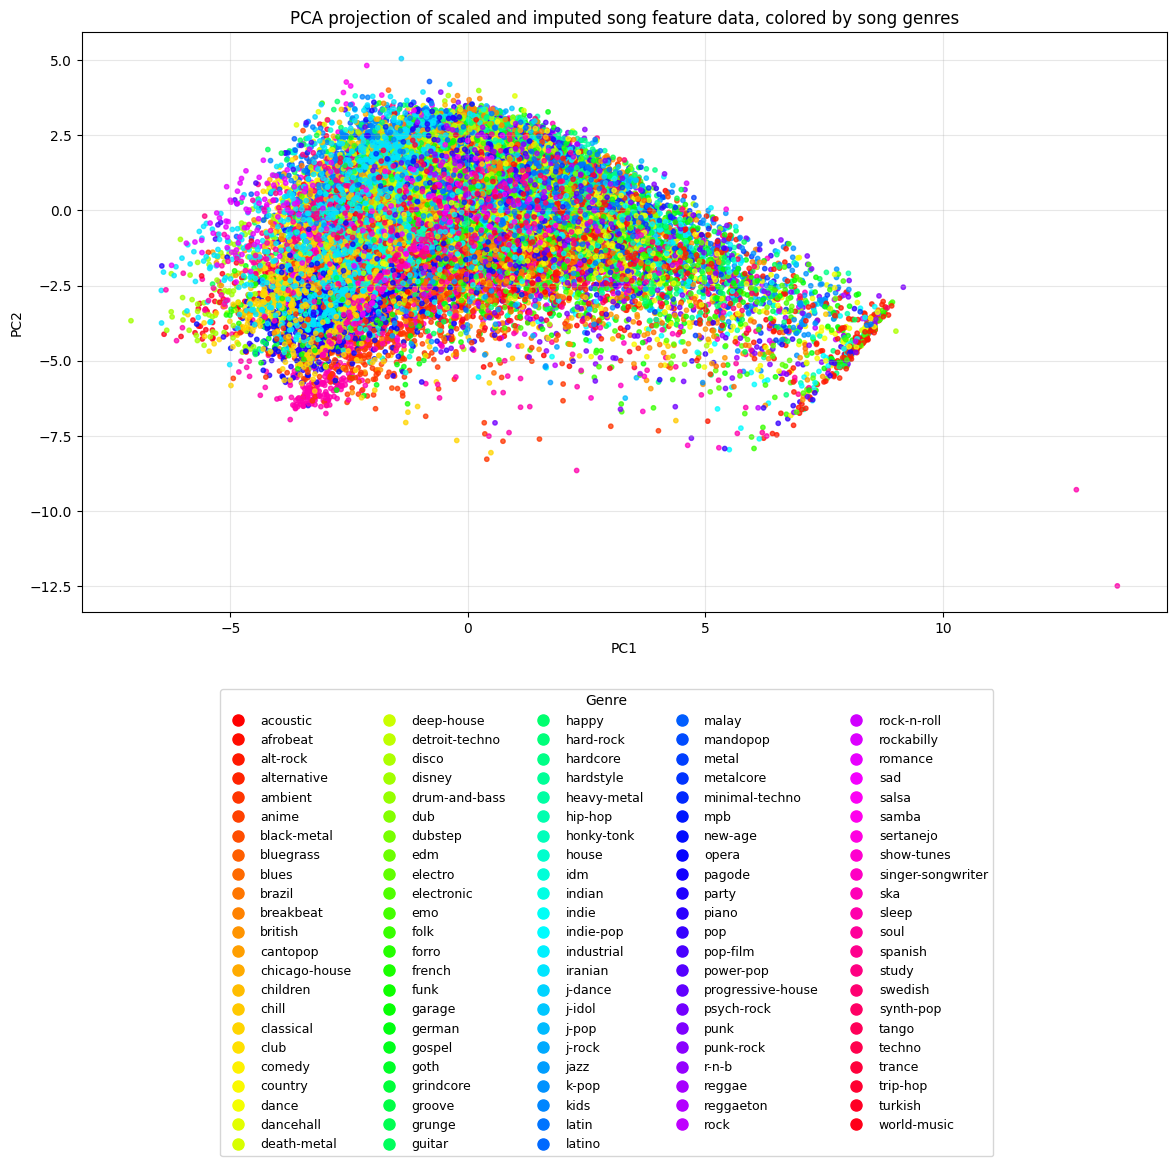

In [4]:
# Prepare labels
genres = df_main["track_genre"].astype("category")
genre_names = genres.cat.categories
genre_codes = genres.cat.codes.values
num_genres = len(genre_names)


# PCA: 
pca = PCA(n_components=2) #2d
X_pca = pca.fit_transform(X_scaled) #Use scaled data for PCA plot


# High-contrast colormap: 
colors = plt.cm.hsv(np.linspace(0, 1, num_genres)) #defines a distinct set of colors for the groups. 
cmap = ListedColormap(colors)

####

# Figure
fig, ax = plt.subplots(figsize=(14, 10))
# Increase bottom margin to make room for horizontal legend
fig.subplots_adjust(bottom=0.3)

# Scatter plot
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=genre_codes,
    cmap=cmap,
    s=10,
    alpha=0.75
)

ax.set_title("PCA projection of scaled and imputed song feature data, colored by song genres")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)


# Legend (horizontal, 5 columns, safely below the plot)
handles = [
    plt.Line2D([], [], marker='o', linestyle='', markersize=8, color=colors[i])
    for i in range(num_genres)
]


fig.legend(
    handles,
    genre_names,
    title="Genre",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),  # move the legend further down
    ncol=5,                        # horizontal 5-column layout
    fontsize=9
)


plt.show()


To explore the data a bit, we make a PCA plot and color based on the song genres. 

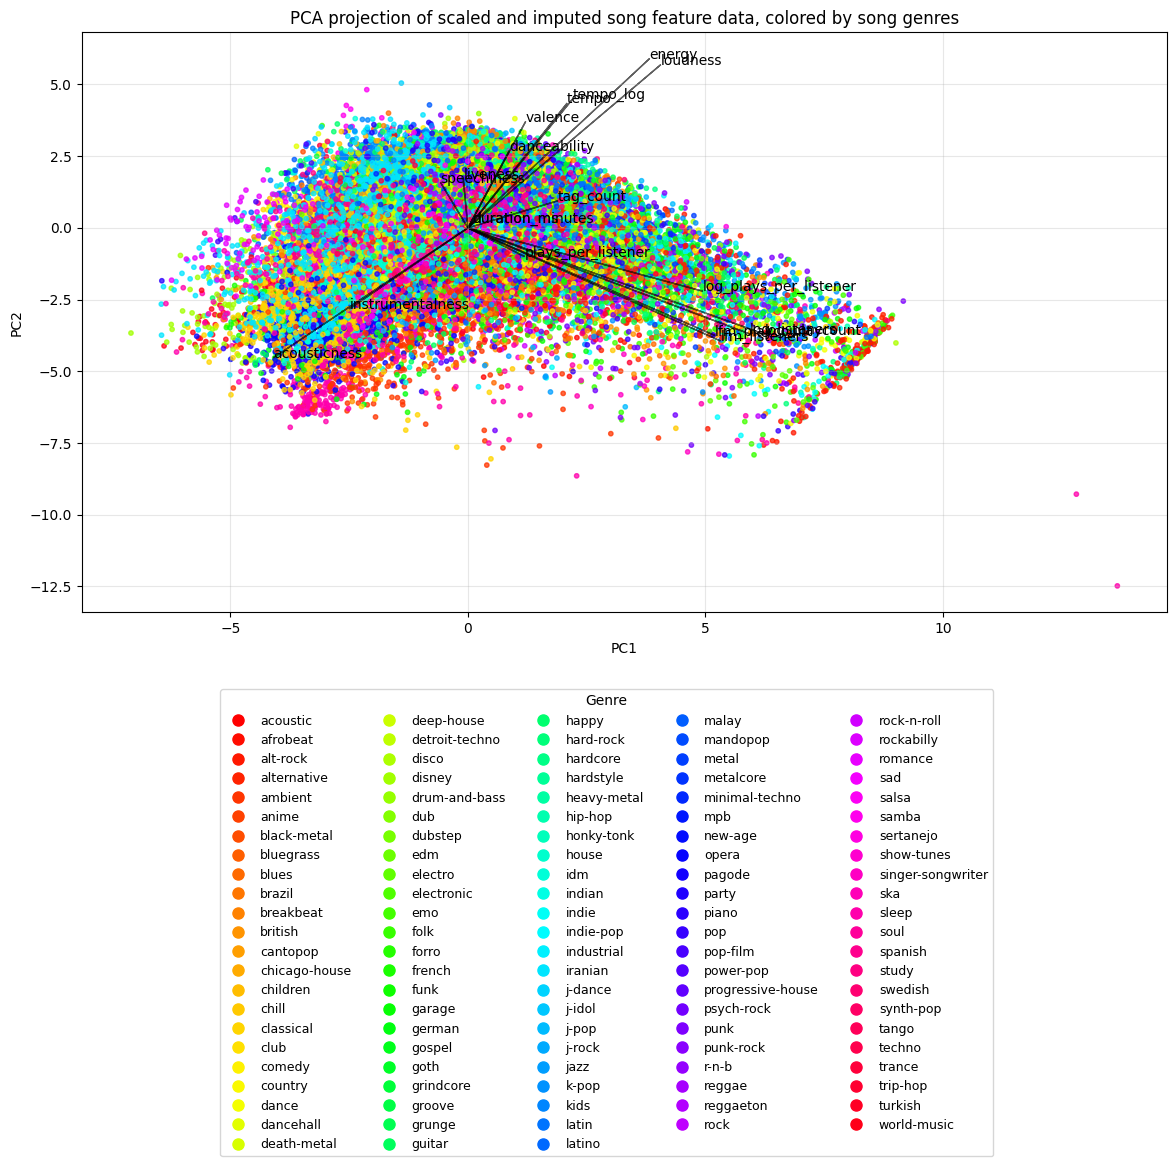

In [5]:
#Same PCA plots as above, but with loading vectors added: 

# Prepare labels
genres = df_main["track_genre"].astype("category")
genre_names = genres.cat.categories
genre_codes = genres.cat.codes.values
num_genres = len(genre_names)


# PCA:
pca = PCA(n_components=2) #2d
X_pca = pca.fit_transform(X_scaled) #Use scaled data for PCA plot


# High-contrast colormap
colors = plt.cm.hsv(np.linspace(0, 1, num_genres)) #defines a distinct set of colors for the groups. 
cmap = ListedColormap(colors)


# Figure
fig, ax = plt.subplots(figsize=(14, 10))
# Increase bottom margin to make room for horizontal legend
fig.subplots_adjust(bottom=0.3)


# Scatter plot
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=genre_codes,
    cmap=cmap,
    s=10,
    alpha=0.75
)

ax.set_title("PCA projection of scaled and imputed song feature data, colored by song genres")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)


# Legend (horizontal, 5 columns, safely below the plot)
handles = [
    plt.Line2D([], [], marker='o', linestyle='', markersize=8, color=colors[i])
    for i in range(num_genres)
]


fig.legend(
    handles,
    genre_names,
    title="Genre",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),  # move the legend further down
    ncol=5,                        # horizontal 5-column layout
    fontsize=9
)

########

# PCA Loadings (feature vectors)
loadings = pca.components_.T   # shape: (num_features, 2)

scale = 15  # Important note: loading vectors are scaled by a factor 15, to make them more visable. 

for i, feature in enumerate(kept_columns): #'kept_columns' are the names of the columns/ features that the imputer didn't remove. 
    ax.arrow(
        0, 0,                         # start at origin
        loadings[i, 0] * scale,
        loadings[i, 1] * scale,
        color='black',
        alpha=0.6,
        width=0.003,
        length_includes_head=True
    )
    ax.text(
        loadings[i, 0] * scale,
        loadings[i, 1] * scale,
        feature,
        fontsize=10
    )


###

plt.show()


Note: The loading vectors were scaled by a factor 15, to make them more visable. 

### **Normal K-means clustering:**

**Quick recap for K-means:**
Centroid, Partition-based. <br>
Requires a user-defined K-value. <br>
*Might* be hard to scale up in some cases. 

In [6]:
# Define k using number of song genres in the data: 

k_value = 50 #Needs to match with what we use for LSH-aided K-means later. 

#If you want to use the amount of unique song genres as k values, uncomment the line below:
#df_main["track_genre"].nunique() 
#(Note: Will lead to worse clustering). 


print()
print("K value is set equals to:", k_value)

####

# Fit global K-means

#How the time consumption is measured for any algorithm: 

t0 = perf_counter() #Timing the code's run time. 

kmeans = KMeans(
    n_clusters=k_value,
    init="k-means++",   #k-means++ algorithm: initializes the centroids + helps speed up initialization and quality of clustering. 
    n_init="auto",      #The algortihm will automatically pick the amount of times to run with different centroid seeds. 
    random_state=42
)

kmeans.fit(X_scaled)
labels = kmeans.labels_

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Main K-means:", t_delta, "sec")
time_dict["main_k_means"] = t_delta
print()


# Add cluster labels back to the dataframe (will be used for evaluation later):

df_main["main_k_mean_cluster"] = labels 
#We will also use another approach for K-means combined with LSH. So for now we will name this one the "main" approach. 

print("Clustering complete:")
display(df_main[["track_genre", "main_k_mean_cluster"]].head(3))


K value is set equals to: 50

Time consumption - Main K-means: 0.7178279019999536 sec

Clustering complete:


,track_genre,main_k_mean_cluster
0,dance,2
1,dance,29
2,latin,7


In [7]:
#Distribution of song genres in different K-means clusters: 
df_cluster_genre_count_compared = pd.crosstab(df_main['track_genre'], df_main['main_k_mean_cluster'])

display(df_cluster_genre_count_compared.head(3))

main_k_mean_cluster,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,33,56,2,7,49,14,44,14,1,0,...,0,9,14,2,0,8,6,0,14,115
afrobeat,1,9,0,64,12,34,37,1,0,1,...,142,3,1,13,0,8,87,0,0,11
alt-rock,0,50,102,7,2,14,46,39,0,0,...,1,0,45,3,0,6,8,0,41,12


**_PCA plotting main K-means clustering_:**

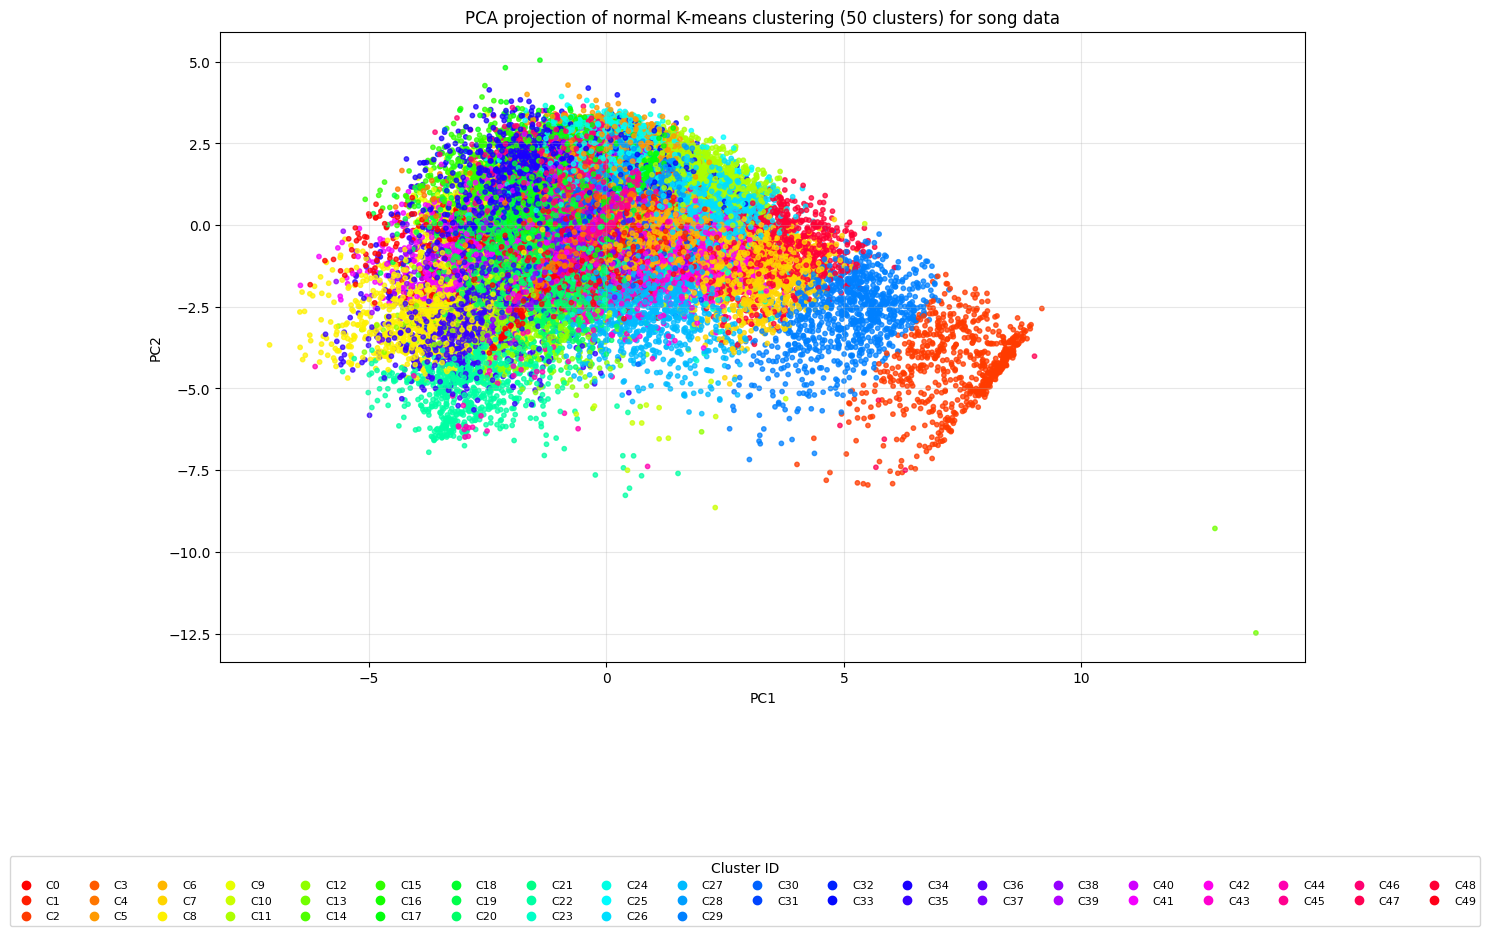

In [8]:
# PCA
pca = PCA(n_components=2) #make it 2d
X_pca = pca.fit_transform(X_scaled) #using scaled data. 

num_clusters = k_value

# High-contrast colormap
colors = plt.cm.hsv(np.linspace(0, 1, num_clusters))

cmap = ListedColormap(colors)


# Figure
fig, ax = plt.subplots(figsize=(14, 10))
fig.subplots_adjust(bottom=0.25)   # Make room at bottom for wide legend


# Scatter plot
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap=cmap,
    s=10,
    alpha=0.75
)

ax.set_title(f"PCA projection of normal K-means clustering ({k_value} clusters) for song data")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)


# Legend (horizontal segmentation)

ncols = 20  #Decides how the amount of columns in the legends is divided up. 

handles = [
    plt.Line2D([], [], marker='o', linestyle='', markersize=6, color=colors[i])
    for i in range(num_clusters)
]

fig.legend(
    handles,
    [f"C{i}" for i in range(num_clusters)],
    title="Cluster ID",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=ncols,
    fontsize=8
)

plt.show()


## **DBSCAN clustering:**

**Quick recap on DBSCAN:** <br>
Density-based. Densly packed. <br>
Note: Usually works well on PCA or UMAP dimensionality-reduced data, <br>
but *can* struggle with high dimensionality. 

In [9]:
# DBSCAN clustering


t0 = perf_counter() #Timing the code's run time. 

print("Running DBSCAN, please wait a bit...")
dbscan = DBSCAN(
    eps=1.8,        # maximum radius between neighbor samples (too small = lot of data gets classified as noise)
    min_samples=3,  # numbers of neighbors required to be considered a 'core point'
    metric='euclidean',
    n_jobs=-1       # -1 = Use all possible CPUs/ parallelize. 
)

labels = dbscan.fit_predict(X_scaled)

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - DBSCAN:", t_delta, "sec")
time_dict["dbscan"] = t_delta
print()


# Add cluster labels back to df (used for evaluation later):
df_main['dbscan_cluster'] = labels #Save the cluster labels, from the DBSCAN, in a column in the dataframe. 


# Summary
n_clusters = len(set(labels)) - (1 if -1 in labels else 0) #Subtract 1 from the number of clusters, if there is a noise cluster (number = -1). 
n_noise = np.sum(labels == -1)
n_total = len(labels)

print()
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} out of {n_total}")
print(f"% amount of noise points: {round(n_noise/n_total*100, 2)}%")

#Note: When we picked a eps value and a min_samples value we tried to reach somewhere around ~50 clusters and less than 15% noise points. 
#It is always a battle between trade-offs. 


Running DBSCAN, please wait a bit...

Time consumption - DBSCAN: 5.543496512999809 sec


Number of clusters found: 73
Number of noise points: 3725 out of 55129
% amount of noise points: 6.76%


In [10]:
#Distribution of song genres in different DBSCAN clusters: 
df_cluster_genre_count_compared = pd.crosstab(df_main['track_genre'], df_main['dbscan_cluster'])

display(df_cluster_genre_count_compared.head(3))

dbscan_cluster,-1,0,1,2,3,4,5,6,7,8,...,63,64,65,66,67,68,69,70,71,72
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,17,718,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
afrobeat,43,703,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alt-rock,38,630,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Note: Cluster number '-1' is the noise cluster. 

**_PCA plotting DBSCAN clustering_:**

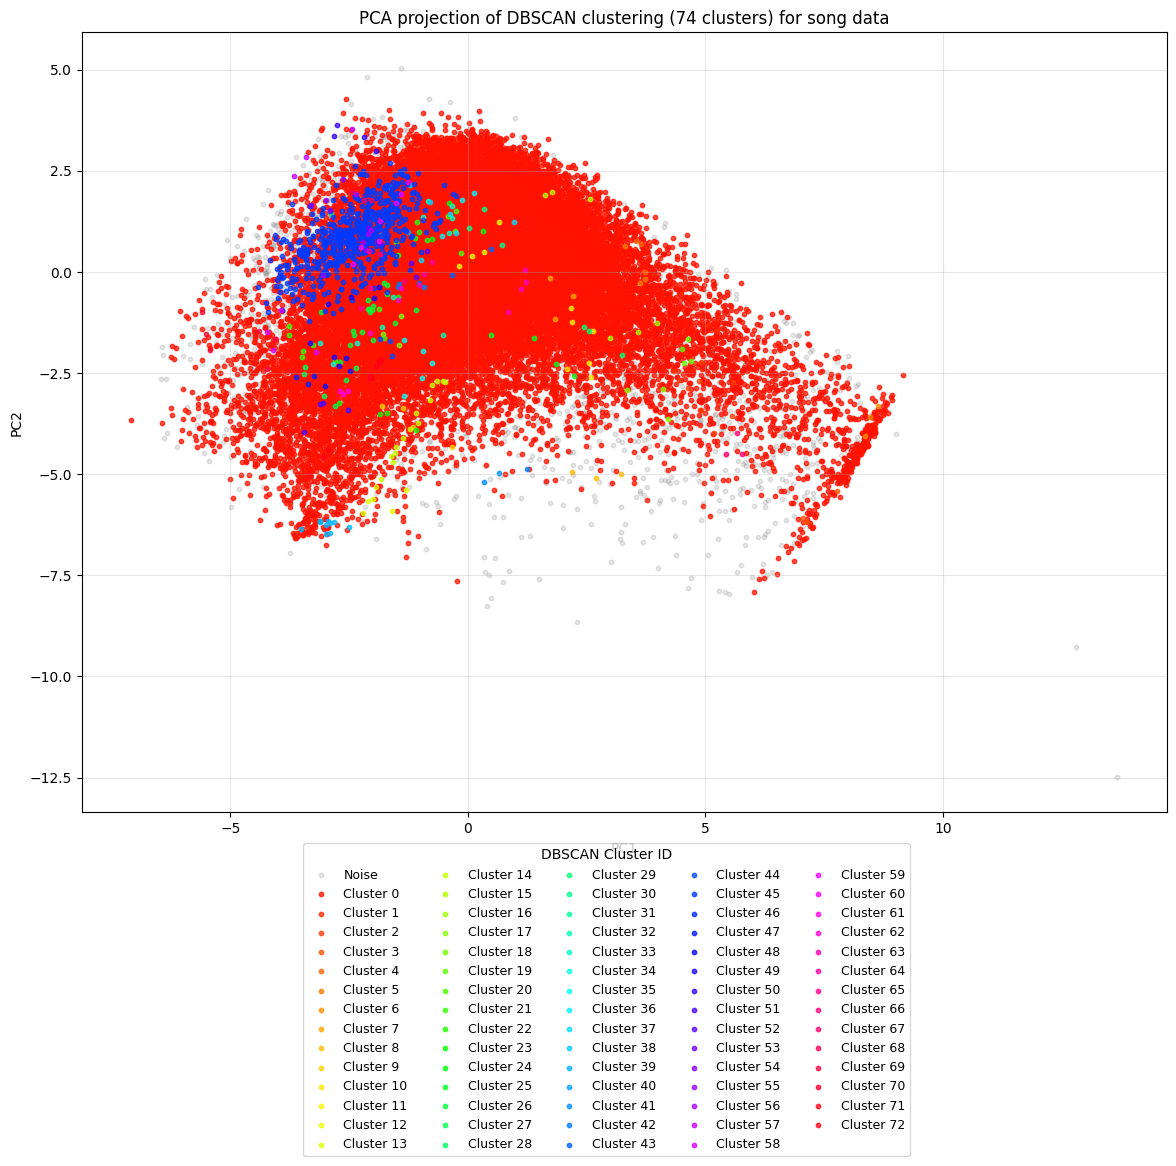

In [11]:
# PCA
pca = PCA(n_components=2) #2d
X_pca = pca.fit_transform(X_scaled) #using scaled (and imputed) data


# DBSCAN clusters: 
unique_labels = np.unique(labels)
num_clusters = len(unique_labels)

# High-contrast colors for clusters (ignore noise, as that needs a special gray color) 
cluster_labels = [l for l in unique_labels if l != -1]
colors = plt.cm.hsv(np.linspace(0, 1, len(cluster_labels)))
cmap = ListedColormap(colors)


# Figure
fig, ax = plt.subplots(figsize=(14, 10))
fig.subplots_adjust(bottom=0.1)  # leave space for horizontal legend


# Scatter plot
handles = []
for i, label in enumerate(unique_labels):
    idx = labels == label
    if label == -1:
        # Noise points: gray & transparent
        sc = ax.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            s=10,
            alpha=0.2,
            color='gray',
            label='Noise'
        )
    else:
        sc = ax.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            s=10,
            alpha=0.75,
            color=colors[i if i < len(colors) else -1],  # safe indexing
            label=f'Cluster {label}'
        )
    handles.append(sc)


ax.set_title(f"PCA projection of DBSCAN clustering ({num_clusters} clusters) for song data")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)


# Legend (horizontal, 5 columns, aka. the 'n_col')
fig.legend(
    handles,
    [h.get_label() for h in handles],
    title="DBSCAN Cluster ID",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=5,
    fontsize=9
)

plt.show()


Notably, the clustering of DBSCAN is not that great. <br>
This is due to the algorithm usually working better at lower dimensionality. <br>
<br>
We can therefore e.g. apply PCA first, in order to reduce dimensionality,<br> 
and then do DBSCAN in order to improve the clustering: 

Running PCA for dimensionality reduction...
Explained variance by 5 components: 100.00%
Variance per component: [9.94777038e-01 3.96840536e-03 1.25455656e-03 2.86148002e-10
 1.04841811e-10]
Running DBSCAN on PCA-reduced data, please wait...
Number of clusters found: 7
Number of noise points: 36549 out of 55129
% amount of noise points: 66.3%

Creating 2D PCA for visualization...
2D PCA explained variance: 35.15%



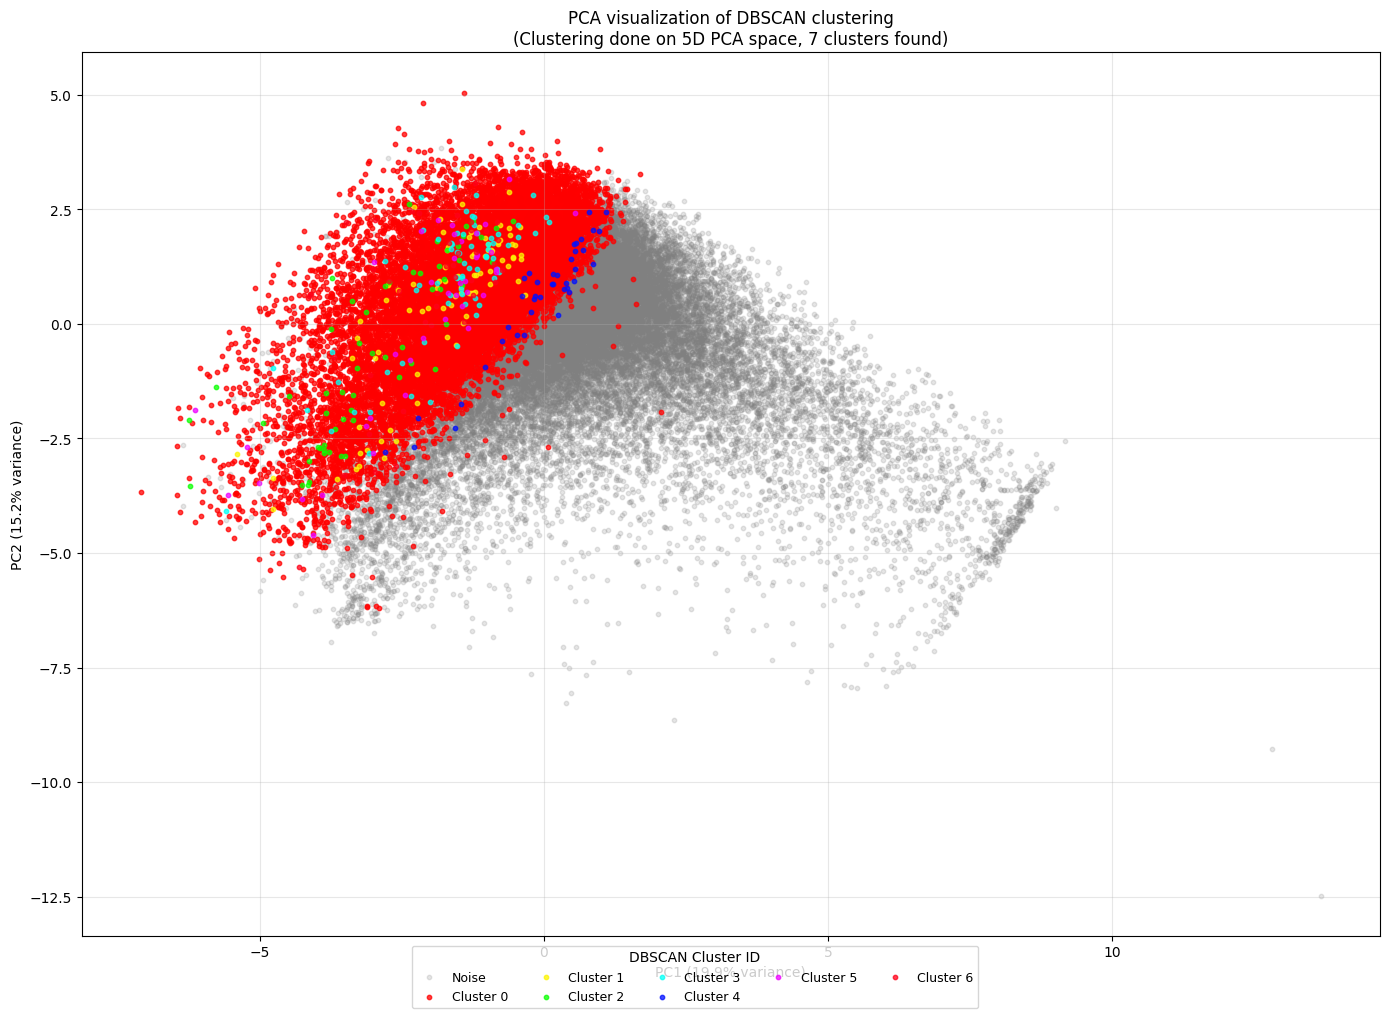

In [12]:

# Trying out PCA for dimensionality reduction (BEFORE DBSCAN clustering): 

#(As DBSCAN can struggle on high-dimensional data, we will try to reduce the dimensionality first using PCA, before applying DBSCAN).



print("Running PCA for dimensionality reduction...")
pca = PCA(n_components=5)  # reduce to 5 dimensions
X_pca_reduced = pca.fit_transform(X)

# Check explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"Explained variance by {pca.n_components_} components: {cumulative_variance[-1]:.2%}")
print(f"Variance per component: {pca.explained_variance_ratio_}")



# DBSCAN clustering (on PCA-reduced data): 

t0_dbscan = perf_counter()

print("Running DBSCAN on PCA-reduced data, please wait...")
dbscan = DBSCAN(
    eps=2000,        #Note: the eps values are quite different compared to the ones we previously used. 
    min_samples=40,  
    metric='euclidean',
    n_jobs=-1       
)

labels = dbscan.fit_predict(X_pca_reduced)



# Add cluster labels back to df 
#df_main['dbscan_cluster'] = labels

#Edit: The clustering is even worse, so we don't add the labels back to the dataframe this time.


# Summary: 
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
n_total = len(labels)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} out of {n_total}")
print(f"% amount of noise points: {round(n_noise/n_total*100, 2)}%")
print()


# PCA for visualization (2D)
print("Creating 2D PCA for visualization...")
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)  # Use original scaled data for visualization

print(f"2D PCA explained variance: {np.sum(pca_2d.explained_variance_ratio_):.2%}")
print()


# Visualization
unique_labels = np.unique(labels)
num_clusters = len(unique_labels)

# High-contrast colors for clusters
cluster_labels = [l for l in unique_labels if l != -1]
colors = plt.cm.hsv(np.linspace(0, 1, len(cluster_labels))) if len(cluster_labels) > 0 else []


#########

# Figure:
fig, ax = plt.subplots(figsize=(14, 10))
fig.subplots_adjust(bottom=0.15)


# Scatter plot
handles = []
for i, label in enumerate(unique_labels):
    idx = labels == label
    if label == -1:
        # Noise points
        sc = ax.scatter(
            X_pca_2d[idx, 0],
            X_pca_2d[idx, 1],
            s=10,
            alpha=0.2,
            color='gray',
            label='Noise'
        )
    else:
        color_idx = cluster_labels.index(label)
        sc = ax.scatter(
            X_pca_2d[idx, 0],
            X_pca_2d[idx, 1],
            s=10,
            alpha=0.75,
            color=colors[color_idx],
            label=f'Cluster {label}'
        )
    handles.append(sc)

ax.set_title(f"PCA visualization of DBSCAN clustering\n(Clustering done on {pca.n_components_}D PCA space, {n_clusters} clusters found)")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
ax.grid(alpha=0.3)

# Legend
fig.legend(
    handles,
    [h.get_label() for h in handles],
    title="DBSCAN Cluster ID",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=5,
    fontsize=9
)

plt.tight_layout()
plt.show()

The dimensionality reduction approach didn't improve the DBSCAN clustering<br>
(Note: We tested various different eps and min_samples in an attempt to optimize, but none lead to great improvements). <br>
<br>
Therefore, we will continue with the full-dimensionality DBSCAN clustering from before, as it was better. <br> 
Even tho the clustering isn't that great, it will be used for baseline when comparing to our own LSH-aided K-means method (see below): 

## **LSH-aided K-means clustering:**

**Background:** <br>

With high computation speed in mind, <br> 
it seemed reasonable to include the previously calculated LSH signatures <br>
and use them as basis for determining super-clusters of some-what similar songs. <br>
<br>
By clustering datapoints based on shared buckets from the LSH signatures, <br> 
we can create super-cluster, <br>
these super-clusters seemed like an interesting starting point for doing K-means clustering on. <br>
They work as a way to pre-divide the different groupings + in an attempt improve the clustering of K-means.

In [13]:
time_dict["LSH_k_means"] = []

**Loading LSH signature data from last notebook:**

In [14]:
LSH = np.load("artifacts/lsh_signatures.npz") #Loading LSH signatures, generated by previous notebook (number 2.)

#Extract some info about the LSH signatures
lsh_bits = LSH["lsh_bits"]           # shape (n_items, 128)
n_tables = int(LSH["n_tables"])      # 8
n_bits_per_table = int(LSH["n_bits_per_table"])  # 16
n_items = lsh_bits.shape[0]

# Split lsh_bits into tables
table_sigs = np.split(lsh_bits, n_tables, axis=1)  # 8 tables

print("LSH bits shape:", lsh_bits.shape)

LSH bits shape: (55129, 128)


**Quick recap of LSH signatures:**<br>
For each datapoint, you ask it 128 questions yes/no (position relative to the 128 random hyperplanes)? Depending on the position, it will either be a yes (1) or a no (0). (Question could e.g. be "is the coordinate in the direction of the normal vector of the given hyperplane? [yes/no]").
If you have, e.g., 8 tables, you start looking at the 16 answers to the questions at a time. (128questions/8tables=16). In other words, if the sequence of answers in table no. 1 is [1,0,...,1,1,0] (length of 16 questions), then this is a unique fingerprint. This specific sequence of answers/ fingerprint for this particular table is called a "bucket". There are several combination options when you have 16 questions in your bucket. In fact, there are 2^16 = 65536 combination options, i.e. there can be 65536 different buckets in this table! If 2 items end up in the same bucket for table 1, then they have identical answers for the first 16 questions. 
Similar datapoints will be on the same side of most hyperplanes, i.e. get mostly the same answers to questions. The pattern in their answers (bits) will be highly similar. If two items differ in only 1 or 2 answers (bits) out of 16, they go in different buckets. But across 8 tables, they'll likely match in at least one table.

**LSH-aided super-clustering:**

In [ ]:
#Important: This code block allows to quickly switch between the imputed data OR the imputed+scaled data. 
#The resulting PCA plots will look quite differently. 
#The 'X = X_imputed', PCA plot arguably has the most visable clustering

#Option 1:
#X = X_imputed

#Option 2
X = X_scaled

#(Comment/ uncomment to use one option at a time). 

In [45]:
#Looping over all buckets in all tables and creating a dict: 

t0 = perf_counter() #Timing the code's run time. 

n_items = lsh_bits.shape[0]
table_sigs = lsh_bits.reshape(n_items, n_tables, n_bits_per_table)

# buckets_per_table[t][bucket_signature] = list of item indices
buckets_per_table = [defaultdict(list) for _ in range(n_tables)]

for t in range(n_tables):
    for i in range(n_items):
        bucket_id = tuple(table_sigs[i, t])
        buckets_per_table[t][bucket_id].append(i)


t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Making dict of songs present in every bucket ID in every table:", t_delta, "sec")
time_dict["LSH_k_means"].append(t_delta)
print()


Time consumption - Making dict of songs present in every bucket ID in every table: 1.5037645949996659 sec



In [46]:
#Example of how the dict works: 
buckets_per_table[0][(1,0,1,1,0,0,0,0,1,1,1,1,0,0,1,0)] #First argument = table number, second argument = bucket ID. 

#Returns the index value of songs in a given bucket. 

[0, 18710, 30279, 39885, 42457, 47845, 47992]

In [47]:
# collision_count[(i,j)] tells how often i and j appear in same bucket
collision_count = defaultdict(int)

t0 = perf_counter() #Timing the code's run time. 

for t in range(n_tables):
    for bucket, items in buckets_per_table[t].items():
        if len(items) <= 1:
            continue
        for i in items:
            for j in items:
                if i < j:
                    collision_count[(i, j)] += 1

#Build final LSH groups
min_collisions = 2   #Important value: The minimum amount of bucket IDs which two songs should share before ending up in the same cluster. 
#Note: as there are 8 tables, it can max be 8. 
#It can be increased in order to acheive more similar/ strict clusters! 
#(Which can help with computation time later on)


lsh_groups = defaultdict(list) #The filtered LSH clustering dict

for (i, j), c in collision_count.items():
    if c >= min_collisions:
        lsh_groups[i].append(j)
        lsh_groups[j].append(i)

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Making dict for how often sets of 2 songs appear in the same bucket:", t_delta, "sec")
time_dict["LSH_k_means"].append(t_delta)
print()




Time consumption - Making dict for how often sets of 2 songs appear in the same bucket: 3.0177918899998986 sec



In [48]:
#Example - looking at first 3 entries of the dicts generated above: 
print(list( collision_count.items() )[:3]) #The non-filtered dict.
print(list( lsh_groups.items() )[:3]) #The filtered dict (needs to share 2 or more buckets in order to end up in the cluster). 

[((0, 18710), 1), ((0, 30279), 1), ((0, 39885), 2)]
[(0, [39885, 42457, 47845, 48840]), (39885, [0, 42457, 47845, 12778, 25611, 46972]), (42457, [0, 39885, 47845, 12778, 25611, 46972])]


In [49]:
#Example of how to use the dict: 

collision_count[(0, 39885)] #In how many tables does e.g. song no. 0 and no. 39885 have identical bits (in the same bucket).
#The answer is 2. I.e. they are in identical buckets/ overlap in 2 tables (2 out of 8 tables). 

2

In [50]:
#Making super-clusters from LSH signatures. It clusters based on when 2 or more datapoints share a lot of buckets. 

t0 = perf_counter() #Timing the code's run time. 

visited = set()
clusters = []

for i in range(n_items): #Up to 55129
    if i in visited:
        continue
    stack = [i]
    comp = [] 
    while stack:
        x = stack.pop() #Pull out most recent element. 
        if x in visited:
            continue
        visited.add(x) #If we already looked on number 1 in relation to number e.g. 1113, then 1113 in relation to 1 is not relevant. Simply skip. 
        comp.append(x) #All items in the cluster. Comp is wiped each time a new stack gets started. 
        stack.extend(lsh_groups[x])
    clusters.append(comp)

# clusters now contain LSH-based super-clusters. 

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Making LSH super-clusters:", t_delta, "sec")
time_dict["LSH_k_means"].append(t_delta)
print()



Time consumption - Making LSH super-clusters: 0.24399049899966485 sec



In [51]:
#Example of what the super-clusters look like: 

#First 2: 
print("How the clusters look like:")
print(clusters[:2])

print()
print(f"Amount of LSH super-clusters: {len(clusters)}") #9,190 super-clusters when n_items = 55,129. 

How the clusters look like:
[[0, 48840, 37804, 47867, 41150, 51388, 33396, 11161, 20681, 41491, 47744, 47845, 46972, 42457, 25611, 39885, 12778], [1, 51441, 43367, 40140, 4037, 20148, 9780, 2324, 28517, 49878, 23877, 38823, 46505, 28595, 41558, 27418, 36870, 10374, 45394, 48030, 50453, 13567, 20514, 48935, 48703, 34636, 10339, 54829, 16352, 46125, 45212, 9017, 4829, 9352, 15960, 54695, 29006, 10503, 51138, 50710, 9264, 47841, 50229, 52574, 30027, 42646, 47469, 53126, 47087, 31283, 40513, 33248, 53655, 28212, 13015, 5789, 11860, 10961, 30002, 2600, 13932, 43945, 37802, 37773, 24198, 25889, 10467, 1632, 52161, 34446, 14013, 50746, 3673, 7001, 54296, 45884, 3253, 67, 43336, 21405, 50500, 28216, 51710, 29402, 31051, 35112, 26697, 45870, 38966, 54308, 10588, 44514, 51160, 52702, 22347, 47652, 42267, 27338, 49993, 43071, 46205, 18262, 43890, 53641, 7299, 24285, 15360, 37345, 27383, 2965, 26951, 36945, 31144, 7510, 19663, 38377, 15777, 7524, 19798, 32150, 32019, 46596, 49971, 6762, 22974, 466

In [52]:
print("What the length distribution of super-clusters (first 20):")
print( [len(c) for c in clusters[:20]] ) #Length distribution of these clusters. 

#Note: Some of them are only 1s. 

What the length distribution of super-clusters (first 20):
[17, 242, 5, 30594, 227, 1, 1, 1, 3, 67, 2, 2, 6, 1, 291, 1, 1217, 482, 927, 11]


In [53]:
#Run LOCAL K-means inside each LSH super-cluster

t0 = perf_counter() #Timing the code's run time. 

local_centroids = []

k_local = 5  # pick 2–10 depending on granularity

for comp in clusters: #Iterate over each LSH cluster
    if len(comp) < k_local:
        # centroid = mean of members
        local_centroids.append(X[comp].mean(axis=0))    #If the cluster has fewer points than k_local (less than 5 songs), 
                                                        #skip K-means and use the mean of all points in the cluster as the centroid.
        continue
        #Note: The reason why it is alright to simply just reduce the small clusters to the mean value (despite the mean not being representative for one for an actual song), 
        #is that we will later map all of the feature values (X) to their nearest global centroid 
        #using 'pairwise_distances_argmin(X, final_centroids)'

    
    km = KMeans(n_clusters=k_local, n_init='auto') #Run K-means on larger clusters
    km.fit(X[comp])
    local_centroids.append(km.cluster_centers_)

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Local K-means on LSH clusters:", t_delta, "sec")
time_dict["LSH_k_means"].append(t_delta)
print()

#Note: as usual, we are using the scaled (and imputed) data. 


Time consumption - Local K-means on LSH clusters: 1.337730496000404 sec



In [54]:
#Looking at the local centroids output: 

print(len(local_centroids))
print(len(local_centroids[0])) #k_local = 5, so there will be 5 clusters. 
print(local_centroids[0]) #5 k-means clusters which was made from the 'clusters' variable. 


9190
5
[[ 2.90990333e+05  1.06938333e+02  4.64281266e+00  4.84983889e+00
   2.57100000e-01  5.50666667e-01  4.70666667e-01  2.75000000e-05
   1.43700000e-01 -1.17796667e+01  4.29000000e-02  3.98333333e-01
   4.48433333e+03  1.24600000e+03  6.70786180e+00  5.81333175e+00
   1.28020242e+00  3.01039227e+00  7.33333333e+00]
 [ 1.56943000e+05  1.31121000e+02  4.87612056e+00  2.61571667e+00
   1.30000000e-02  7.14000000e-01  4.72000000e-01  4.51000000e-06
   2.66000000e-01 -7.37500000e+00  8.64000000e-02  2.38000000e-01
   1.09952500e+07  9.20570000e+05  1.62129740e+01  1.37327494e+01
   2.56062916e+00  1.19439586e+01  5.00000000e+00]
 [ 1.75986000e+05  7.71170000e+01  4.34532375e+00  2.93310000e+00
   7.64000000e-01  5.93000000e-01  2.87000000e-01  0.00000000e+00
   1.53000000e-01 -1.24720000e+01  4.69000000e-02  6.39000000e-01
   1.52021400e+06  5.20870000e+05  1.42343623e+01  1.31632577e+01
   1.36573583e+00  2.91860541e+00  1.00000000e+01]
 [ 1.52989700e+05  1.26911900e+02  4.81157146e+0

In [55]:
#Flatten, i.e. stack all local centroids: 

#Unifying the centroids. 
#Combine all centroids (from both small and large clusters) into a single matrix, where each row is a centroid.

t0 = perf_counter() #Timing the code's run time. 

local_centroids = np.vstack([
    c if c.ndim == 2 else np.expand_dims(c, axis=0) #If centroid is already 2D (c.ndim == 2), use it as-is.
                                                    #If c is 1D (e.g., from a small cluster), reshape it to 2D 
                                                    #using np.expand_dims(c, axis=0). 
                                                    #This adds a new axis, converting a 1D array of shape (n_features,) to (1, n_features)
    for c in local_centroids
])

t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Unifying local K-means on LSH clusters:", t_delta, "sec")
time_dict["LSH_k_means"].append(t_delta)
print()

#In short: Converts shape (n_features,) to (1, n_features), for the really small clusters. 


Time consumption - Unifying local K-means on LSH clusters: 0.025072599999475642 sec



In [56]:
#After flattening: 
print(len(local_centroids))
print(local_centroids)


11614
[[2.90990333e+05 1.06938333e+02 4.64281266e+00 ... 1.28020242e+00
  3.01039227e+00 7.33333333e+00]
 [1.56943000e+05 1.31121000e+02 4.87612056e+00 ... 2.56062916e+00
  1.19439586e+01 5.00000000e+00]
 [1.75986000e+05 7.71170000e+01 4.34532375e+00 ... 1.36573583e+00
  2.91860541e+00 1.00000000e+01]
 ...
 [1.31000000e+05 1.06807000e+02 4.67102347e+00 ... 1.72092993e+00
  5.46458100e+00 0.00000000e+00]
 [1.23535000e+05 9.45590000e+01 4.54922398e+00 ... 1.72092993e+00
  5.46458100e+00 0.00000000e+00]
 [1.78066000e+05 1.20216000e+02 4.78929012e+00 ... 1.72092993e+00
  5.46458100e+00 0.00000000e+00]]


In [57]:
#Run global K-means on local centroids - produces final centroids:

t0 = perf_counter() #Timing the code's run time. 


k_global = 50  # final number of clusters

km_global = KMeans(
                   n_clusters=k_global, #k = 50
                   n_init='auto')

km_global.fit(local_centroids) #use local centroids as datapoints for global K-means (we just got these from the previous step).

final_centroids = km_global.cluster_centers_


t1 = perf_counter() #Timing the code's run time. 
t_delta = t1-t0 #Timing the code's run time. 
print()
print("Time consumption - Global K-means on using local centroids (LSH clusters):", t_delta, "sec")
time_dict["LSH_k_means"].append(t_delta)
print()



Time consumption - Global K-means on using local centroids (LSH clusters): 0.11366679999991902 sec



In [58]:
#Assign points to the final centroid: 
labels_global = pairwise_distances_argmin(X, final_centroids) #all feature data points in X are assigned to the nearest final centroid


In [59]:
labels_global

array([46, 24,  6, ..., 33, 33, 33], shape=(55129,))

**_PCA plotting of LSH-aided K-means clustering_:**

In [75]:
#Making a function for PCA plotting clusters: 

def plot_clusters_pca(X, labels_global, sample_size=20000):

    #Note: The sample_size parameter allows downsampling for large datasets, 
    #to make plotting with less datapoints, to make them more visable/ less cluttered.
    #However, this feature was mainly just made during the prototyping phase. 

    # Input:
    #   X               : (n_items, d) feature matrix
    #   labels_global   : (n_items,) cluster assignments

    n = X.shape[0]

    # Downsample large datasets for visualization
    if n > sample_size:
        idx = np.random.choice(n, size=sample_size, replace=False)
        X_vis = X[idx]
        labels_vis = labels_global[idx]
    else:
        X_vis = X
        labels_vis = labels_global

    # PCA -> 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vis)

    # Create figure
    plt.figure(figsize=(10, 7))

    # Avoid color issues: pass labels as *a separate argument*
    # and let matplotlib assign a colormap
    scatter = plt.scatter(
        X_pca[:, 0], 
        X_pca[:, 1], 
        c=labels_vis,
        s=8,
        alpha=0.7,
        cmap="tab20"
    )

    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("Cluster ID", rotation=270, labelpad=15)

    plt.title("PCA visualization of LSH-aided K-means clusters")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    plt.tight_layout()
    plt.show()


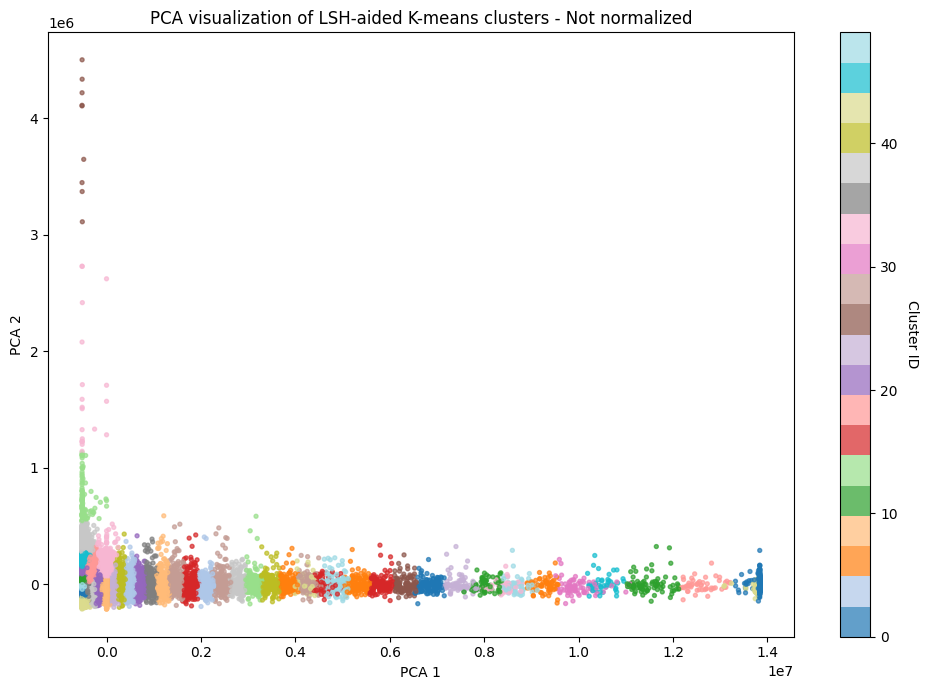

In [74]:
plot_clusters_pca(X, labels_global, sample_size=X.shape[0]) #Prevent downsampling, by passing full lenght. 

#You can however reduce the amount of illustrated datapoints, by setting 'sample_size=1000' or a corresponding low value. 

#Note: 'labels_global.shape[0]' is the same as 'X.shape[0]'

Note that this clustering is actually really impressive compared to the 2 other algorithms<br> 
which we have used in this notebook! 

<br>
<br>
<br>
<br>



**Comparison:**

- PCA for imputed data: <br>

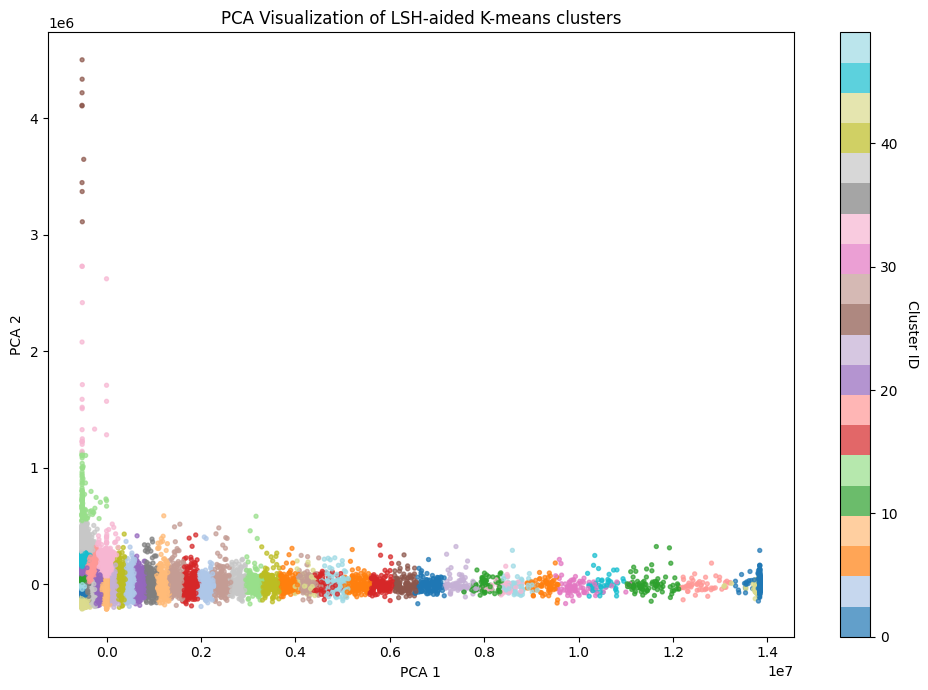

(You could argue that not using the scaled data gives an even better clustering). 

- PCA for imputed+scaled data: <br>

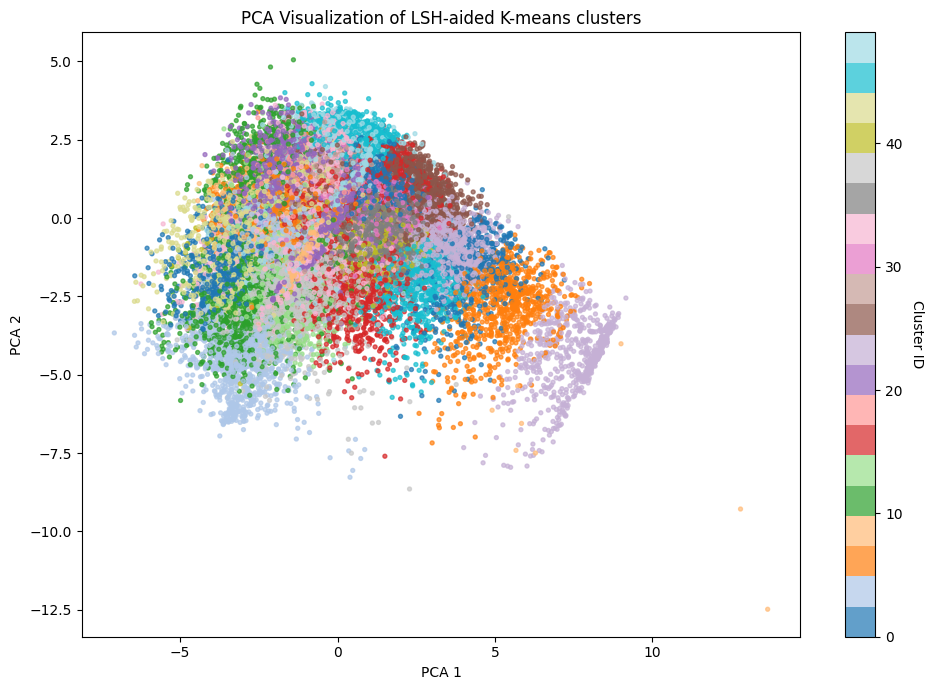

(Same as above, if you are using the default version of the notebook)



In [62]:
#Adding the LSH-aided K-means clusters to the dataframe:

df_main['LSH_k_mean_cluster'] = labels_global #Save the cluster labels, from the DBSCAN, in a column in the dataframe. 

In [63]:
#Distribution of song genres in different LSH-aided K-means clusters: 
df_cluster_genre_count_compared = pd.crosstab(df_main['track_genre'], df_main['LSH_k_mean_cluster'])

display(df_cluster_genre_count_compared.head(3))

LSH_k_mean_cluster,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,101,1,1,9,12,0,2,0,27,5,...,3,17,18,0,0,3,0,0,3,152
afrobeat,89,0,0,0,1,0,0,0,6,1,...,0,3,16,0,0,32,0,0,0,212
alt-rock,18,11,75,6,11,7,13,3,21,10,...,11,22,1,2,0,2,6,2,10,66


## **Comparing the 3 clustering methods:**

This notebook has now demonstrated 3 ways of clustering the song feature data. <br>
2 of the methods are part of curriculum. <br>
The 3'rd one is a innovative new approach which combines methods from the course. <br>
<br>
It is now time to evaluate how well these 3 clustering methods will cluster similar songs <br>
and thereby helping provide a proper subset for the music recommender to sample from. 

In [64]:
df_main[["main_k_mean_cluster","dbscan_cluster","LSH_k_mean_cluster"]].head(5)

,main_k_mean_cluster,dbscan_cluster,LSH_k_mean_cluster
0,2,-1,46
1,29,0,24
2,7,0,6
3,29,0,32
4,29,0,5


We will now pick 100 random songs, look up their corresponding clusters (from each of the 3 methods) <br>
and will then use nearest neighbor (cosine similarity) to find the 5 most similar songs in each cluster. 

In [65]:
#Just to briefly sum up: 

#Main numeric data from the df_main dataframe:
print(X)

#Cluster labels: 
display(df_main[["main_k_mean_cluster","dbscan_cluster","LSH_k_mean_cluster"]])

#Task:
#We will now pick 10 random songs, look up their corresponding clusters (from each of the 3 methods)
#and will then use nearest neighbor (cosine similarity) to find the 5 most similar songs in each cluster. 


[[1.56943000e+05 1.31121000e+02 4.87612056e+00 ... 2.56062916e+00
  1.19439586e+01 5.00000000e+00]
 [1.75238000e+05 1.28040000e+02 4.85234272e+00 ... 2.43721512e+00
  1.04411342e+01 5.00000000e+00]
 [1.62637000e+05 1.24980000e+02 4.82815372e+00 ... 2.55256785e+00
  1.18400327e+01 1.00000000e+01]
 ...
 [3.47826000e+05 1.38047000e+02 4.92759421e+00 ... 1.72092993e+00
  5.46458100e+00 0.00000000e+00]
 [3.09250000e+05 1.42045000e+02 4.95614391e+00 ... 1.72092993e+00
  5.46458100e+00 0.00000000e+00]
 [4.06308000e+05 1.49996000e+02 5.01060863e+00 ... 1.72092993e+00
  5.46458100e+00 0.00000000e+00]]


,main_k_mean_cluster,dbscan_cluster,LSH_k_mean_cluster
0,2,-1,46
1,29,0,24
2,7,0,6
3,29,0,32
4,29,0,5
...,...,...,...
55124,38,0,8
55125,38,0,8
55126,45,-1,33
55127,4,0,33


In [66]:
#Fill out: 

#Amount of random songs that the code should sample, check e.g. top 100 most similar songs for:
sample_size = 100 

#Top y amount of most similar songs:
n_most_similar = 5

In [67]:
#setup and seeding: 

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Convert X to numpy array (safety check)
X_mat = X.values if hasattr(X, "values") else X


#####

# Select 10 random indices
n_items = X_mat.shape[0]
random_indices = np.random.choice(n_items, size=sample_size, replace=False)

random_indices


array([30989, 34997, 48619, 47408, 40015, 15578, 38922, 10901, 51878,
       25011, 20512,  8161,  2593, 21915, 36857,  2608, 45702, 33047,
       53925, 26492, 40513, 29170, 13664, 47043, 21189, 30239, 50141,
       14773, 40109, 31567, 17523, 35727, 42052,  4679, 22935,  6527,
       23166, 38205, 47825, 20628, 31242, 21121, 54532, 32114, 50582,
       16420, 51067, 45701, 44217,  3154,  7024, 33608, 11041, 32724,
       16419,  6707, 25328, 43699, 22275,  3609, 16100, 31503,  7481,
        6975, 39766, 27084, 36381, 43854, 49752, 47156, 14960, 10520,
       38399, 23181,  5488, 41067, 53347,  1583, 22790, 45299, 23330,
       39058, 35958,  3095,  9459,  4969, 27123,  7278, 31659, 41261,
       21234, 30398,  4503, 16935, 35781, 41817, 31554, 19223, 20050,
       35040])

In [68]:
#Make function for e.g. finding the top 5 most similar songs for a given song, 
#given the index of the song + input like ' df_main["main_k_mean_cluster"] ', or similar cluster subset info.


def top_k_similar_in_cluster(target_idx, cluster_series, k=5):
    """
    target_idx: index of song to compare against
    cluster_series: df_main[cluster_column] (one column)
    k: the amount of most similar songs it should find. Top 5 most similar songs is the default output
    """
    cluster_label = cluster_series.iloc[target_idx]

    #Find indices of songs in same cluster: 
    cluster_members = cluster_series[cluster_series == cluster_label].index.values

    #Exclude the target index itself
    cluster_members = cluster_members[cluster_members != target_idx]

    #Cosine similarity between target song and all members
    sims = cosine_similarity(
        X_mat[target_idx].reshape(1, -1),
        X_mat[cluster_members]
    ).flatten()

    #Top-k most similar songs: 
    top_k_idx = cluster_members[np.argsort(sims)[::-1][:k]]

    return list(top_k_idx), sims[np.argsort(sims)[::-1][:k]]


In [69]:
#Getting the results - finding the e.g. top 5 most similar songs, out of the e.g. 10 random samples

results = []

cluster_cols = [
    "main_k_mean_cluster",
    "dbscan_cluster",
    "LSH_k_mean_cluster"
]

for song_idx in random_indices:
    entry = {
        "song_index": song_idx
    }

    for col in cluster_cols:
        top_idx, sims = top_k_similar_in_cluster(song_idx, df_main[col], n_most_similar)
        entry[col + "_neighbors"] = top_idx
        entry[col + "_similarities"] = sims

    results.append(entry)

#Convert to DataFrame for readability: 
results_df = pd.DataFrame(results)

results_df


,song_index,main_k_mean_cluster_neighbors,main_k_mean_cluster_similarities,dbscan_cluster_neighbors,dbscan_cluster_similarities,LSH_k_mean_cluster_neighbors,LSH_k_mean_cluster_similarities
0,30989,"[19953, 29823, 33039, 24620, 29744]","[0.9999999999042849, 0.999999996345731, 0.9999...","[19953, 29823, 33039, 42873, 34135]","[0.9999999999042849, 0.999999996345731, 0.9999...","[29823, 42873, 24620, 36255, 42611]","[0.999999996345731, 0.9999999959433632, 0.9999..."
1,34997,"[47963, 46996, 47995, 33859, 46992]","[0.9999981368525623, 0.9999958656464336, 0.999...","[34467, 16535, 40659, 38570, 31661]","[0.9999996901600737, 0.9999996502626467, 0.999...","[40659, 46576, 28502, 24172, 46996]","[0.9999996412391545, 0.9999989956156501, 0.999..."
2,48619,"[37800, 46859, 38615, 32390, 47128]","[0.9999998373662539, 0.9999993415102226, 0.999...","[26646, 47377, 37800, 36978, 44517]","[0.9999999554006286, 0.9999999017821065, 0.999...","[37800, 36978, 44517, 51404, 51955]","[0.9999998373662539, 0.9999995247934512, 0.999..."
3,47408,"[43900, 47931, 22807, 47932, 44811]","[0.9999982368084405, 0.999997977940639, 0.9999...","[39772, 33607, 36117, 48458, 30905]","[0.9999997312243519, 0.9999989753061715, 0.999...","[39772, 33607, 46486, 28666, 32342]","[0.9999997312243519, 0.9999989753061715, 0.999..."
4,40015,"[23663, 47098, 27918, 51387, 27026]","[0.9999958168563139, 0.9999932392763022, 0.999...","[14069, 37302, 9512, 24691, 43079]","[0.9999998688125, 0.9999994825384929, 0.999999...","[37302, 24691, 43079, 42875, 38883]","[0.9999994825384929, 0.9999992355721076, 0.999..."
...,...,...,...,...,...,...,...
95,41817,"[40412, 40295, 40410, 33358, 38799]","[0.9999999890276426, 0.9999999883656222, 0.999...","[40412, 40295, 40410, 33358, 38799]","[0.9999999890276426, 0.9999999883656222, 0.999...","[21370, 30052, 43140, 47605, 41057]","[0.9999999975807125, 0.9999999866515258, 0.999..."
96,31554,"[24574, 27124, 51103, 20869, 13941]","[0.9999997151341878, 0.9999993090980412, 0.999...","[31881, 13949, 36068, 43487, 36666]","[0.9999998843380796, 0.9999998642316609, 0.999...","[22785, 28748, 18457, 23240, 39347]","[0.999999740563687, 0.9999995379083717, 0.9999..."
97,19223,"[26313, 16584, 22993, 31516, 15680]","[0.9999965463491747, 0.9999951663824681, 0.999...","[47856, 34097, 52647, 47902, 35105]","[0.9999995615067386, 0.999999302262369, 0.9999...","[41839, 34097, 37396, 35105, 35081]","[0.9999994751123114, 0.999999302262369, 0.9999..."
98,20050,"[15251, 24437, 41012, 43968, 33760]","[0.9999986970836962, 0.9999970123518909, 0.999...","[24961, 11285, 26660, 2810, 8926]","[0.9999999560446806, 0.9999999152833919, 0.999...","[30984, 6707, 23884, 22686, 22938]","[0.9999995991941588, 0.999999566605544, 0.9999..."


In [70]:
#Finding the mean and standard deviation across the results above, for each of the 3 methods: 

similarity_stats = {}

for col in cluster_cols:   # ["main_k_mean_cluster", "dbscan_cluster", "LSH_k_mean_cluster"]

    all_sims = []
    for entry in results:
        sims = entry[col + "_similarities"]
        all_sims.extend(sims)

    all_sims = np.array(all_sims)

    similarity_stats[col] = {
        "mean_similarity":  all_sims.mean(),
        "std_similarity":   all_sims.std()
    }

#Convert to DataFrame to make easier to read:
similarity_stats_df = pd.DataFrame(similarity_stats).T
similarity_stats_df


,mean_similarity,std_similarity
main_k_mean_cluster,0.999935,0.000316
dbscan_cluster,0.999986,0.000118
LSH_k_mean_cluster,0.999951,0.000358


In [71]:
#4'th option is comparing it to some completely random songs from the entire dataset. 
n_most_similar

# 4th comparison: random (n_most_similar amount of) neighbors from full dataset: 
baseline_results = []

for song_idx in random_indices:

    #Pick (n_most_similar amount of) random distinct songs (not including the target)
    pool = np.arange(n_items)
    pool = pool[pool != song_idx]
    random_neighbors = np.random.choice(pool, size=n_most_similar, replace=False)

    sims = cosine_similarity(
        X_mat[song_idx].reshape(1, -1),
        X_mat[random_neighbors]
    ).flatten()

    baseline_results.append(sims)


#Flatten into a single vector of similarity values: 
baseline_sims = np.concatenate(baseline_results)

baseline_mean = baseline_sims.mean()
baseline_std  = baseline_sims.std()
similarity_stats["random_baseline"] = {
    "mean_similarity": baseline_mean,
    "std_similarity": baseline_std
}

similarity_stats_df = pd.DataFrame(similarity_stats).T
display(similarity_stats_df) #The results, now including the random baseline. 

,mean_similarity,std_similarity
main_k_mean_cluster,0.999935,0.000316
dbscan_cluster,0.999986,0.000118
LSH_k_mean_cluster,0.999951,0.000358
random_baseline,0.784456,0.298897


**Conclusion:** <br>
It is noticable that given these evaluation criteria, <br> 
and given this very specific set of parameters used for these methods, <br>
we have arrived at fairly statistically similar set of results (evaluating based on cosine similarity, assuming that it is the ground-truth). <br>
All of these algorithms beat the random baseline, by far, in terms of average cosine similarity. 

The evaluation of the DBSCAN clusters might however be a bit misleading, <br>
as we observed on the PCA plot of the DBSCAN clusters, that it primarily formed just 1 big cluster. <br>
<br>
When using the cosine-similarity/ look-up approach, most of the songs would probably just go to the giant cluster <br>
And search against the giant cluster (which thus wouldn't reduce computation all that much!) <br>
<br>
On the other hand, the PCA plot for the LSH-aided K-means clustering showed surprisingly good clustering! 

**Inspecting time consumption:**

In [72]:
t_pretreatment = sum(time_dict["pretreatment"])
t_main_k_means = time_dict["main_k_means"]
t_dbscan = time_dict["dbscan"]
t_LSH_k_means = sum(time_dict["LSH_k_means"])

print("Time consumption of:")
print("Normal K-means clustering:", t_pretreatment+t_main_k_means, "sec")
print("DBSCAN clustering:", t_pretreatment+t_dbscan, "sec")
print("LSH-aided K-means clustering:", t_pretreatment+t_LSH_k_means, "sec")

Time consumption of:
Normal K-means clustering: 0.762784401999852 sec
DBSCAN clustering: 5.588453012999707 sec
LSH-aided K-means clustering: 12.631188198997734 sec


Running normal K-means clustering on the entire dataset is the fastest, <br>
and LSH-aided K-means clustering is generally the slowest, <br>
however, when we experimented with other parameters, the DBSCAN was the slowest - so it also depends a lot on the parameter choice. 

**Conclusion:** <br>
Although LSH-aided K-means clustering still hasn't been 100% optimized for speed, <br>
it still achieved an impressive clustering in the PCA, <br>
by utilizing an unique approach to initialization of K-means. <br>
<br>
By utilizing and exploring these clusters, <br>
we might be able to pick subsets which are approariate for our, <br>
song recommender to sample from, in order to save computation time. 